# Training a Bayesian Belief Net using EM Algorithm

Author: Usama Muneeb

To link to this notebook, please use the URL of the repository: https://github.com/usamamuneeb/expectation-maximization-beliefnet

In [1]:
import numpy as np
import time

## Defining the Belief Net

We define the network by defining

1. The nodes
2. Their number of possible states
3. The parents of every node
4. The nodes we want to update (we may choose to update a subset of the nodes)

The word **node** and **variable** may be used interchangeably throughout the notebook.

In [2]:
# give descriptive names to each node
graphNodes = ["a", "b", "c", "d", "e", "f", "g", "h"]

# serves as inverse mapping of above
graphNodeIndices = {}
for idx, node in enumerate(graphNodes):
    graphNodeIndices[node] = idx

# define number of possible states for each node
# the set of states then becomes {0, 1, .... graphNodeNumStates["node"]-1}
graphNodeNumStates = {
    "a": 3,
    "b": 4,
    "c": 5,
    "d": 4,
    "e": 3,
    "f": 4,
    "g": 5,
    "h": 4
}

# user may choose to update only a subset of nodes
nodesToUpdate = ["a", "b", "c", "d", "e", "f", "g", "h"]

# each node has the following parents (this defines the directed edges of the Belief Net)
# make sure there are no cycles
nodeParents = {
    "a": [],
    "b": [],
    "c": ["a"],
    "d": ["a", "b"],
    "e": ["a", "c"],
    "f": ["b", "d"],
    "g": ["e"],
    "h": ["f"]
}

# define what variable/node each dimension in the probability tensors `p`, `phat` and `q` will correspond to
tensorNodeOrder = {}
for node in graphNodes:
    tensorNodeOrder[node] = [node] + nodeParents[node]

The last dictionary `tensorNodeOrder` is very important. It will specify what variable each dimension of the probability tensors in `p`, `phat` and `q` will represent.

Before adding something to the tensors in `p`, `phat` and `q`, we will sort it according to the order specified by `tensorNodeOrder[node]` so that it turns out to have the same order of indices and dimensions as the tensors it's being added to.

Besides that, we will not have sorted indices all the time in the intermediate computations. Instead, we will be maintaining a list (or lists) containing the sequence of variables corresponding to each dimension in the tensor (or tensors) upon which the operation is being performed.

## Generate the probability distributions

We generate or hardcode the true probability distribution tensors of each node given it's parents.

### Generate/specify the true probability distributions  $P$ for each node

Generate `p`, the dictionary of true probability tensors.

In [3]:
def randomTensorGenerator(shape):
    return np.random.uniform(0.0, 1.0, shape)

def conditionNodeOnParents(probTensor, node, tensorNodeOrder):
    # makes all probabilities sum to 1 along the dimension of the variable being inferred
    assert(node in tensorNodeOrder)
    inferredDimension = tensorNodeOrder.index(node)
    probTensor = probTensor / np.expand_dims(np.sum(probTensor, inferredDimension), inferredDimension)
    return probTensor

# Method 1: randomly generate `p` (true distribution) matrix
# (set a seed to have a reproducable `p`)
np.random.seed(0)
p = {}
for node in graphNodes:
    tensorDimensions = [graphNodeNumStates[x] for x in tensorNodeOrder[node]]
    p[node] = randomTensorGenerator(tensorDimensions)

# make all probabilities sum to 1 along the dimension of the variable being inferred (condition on parents)
for node in p:
    p[node] = conditionNodeOnParents(p[node], tensorNodeOrder[node][0], tensorNodeOrder[node])
    print("p(" + node + "|" + str(nodeParents[node]) + ") dimensions: " + str(p[node].shape))

# Method 2: hardcode `p`
# e.g.
# p = {
#     "x": np.array([0.1, 0.9]),
#     "y": np.array([[0.05,0.01],[0.95,0.99]]),
#     "z": np.array([[0.05,0.01],[0.95,0.99]])
# }

p(a|[]) dimensions: (3,)
p(b|[]) dimensions: (4,)
p(c|['a']) dimensions: (5, 3)
p(d|['a', 'b']) dimensions: (4, 3, 4)
p(e|['a', 'c']) dimensions: (3, 3, 5)
p(f|['b', 'd']) dimensions: (4, 4, 4)
p(g|['e']) dimensions: (5, 3)
p(h|['f']) dimensions: (4, 4)


### Randomly initialize the estimated probability distributions  $\hat{P}$ for each node

Generate `phat`, the dictionary of estimated probability tensors. We will train them using EM.

In [4]:
# set the seed (pseudo)randomly
# (we want `phat` to be initialized randomly, so multiple runs can give different starting points)
np.random.seed(int(time.time()))

phat = {}

# initialize a `phat` corresponding to all true probability (`p`) tensors (not just those in `nodesToUpdate`)
# we will simply not update them if they aren't listed in `nodesToUpdate`
for node in p:
    phat[node] = randomTensorGenerator(p[node].shape)
    phat[node] = conditionNodeOnParents(phat[node], tensorNodeOrder[node][0], tensorNodeOrder[node])
    print("phat(" + node + "|" + str(nodeParents[node]) + ") dimensions: " + str(phat[node].shape))

phat(a|[]) dimensions: (3,)
phat(b|[]) dimensions: (4,)
phat(c|['a']) dimensions: (5, 3)
phat(d|['a', 'b']) dimensions: (4, 3, 4)
phat(e|['a', 'c']) dimensions: (3, 3, 5)
phat(f|['b', 'd']) dimensions: (4, 4, 4)
phat(g|['e']) dimensions: (5, 3)
phat(h|['f']) dimensions: (4, 4)


## Define some helper functions

#### Function `multiplyTensorsOverVars`

**Takes**:

1. `tensorA`: first tensor and
2. `nodesTensorA`: a list specifying what variable (node) each dimension in the first tensor corresponds to
3. `tensorB`: second tensor and
4. `nodesTensorB`: a list specifying what variable (node) each dimension in the second tensor corresponds to

(Length of each list is the same as the number of dimensions in the corresponding tensor.)

**Returns**:

1. A combined tensor and
2. a list specifying what variable (node) the corresponding dimension in the combined tensor corresponds to

In [5]:
def multiplyTensorsOverVars(tensorA, nodesTensorA, tensorB, nodesTensorB):
    if len(nodesTensorA)==0:
        # sometimes the case when combining missing with present (no present vars)
        # sometimes the case when multiplying the missing together
        nodesCombinedTensor = nodesTensorB
        combinedTensor = tensorA * tensorB
    elif len(nodesTensorB)==0:
        # sometimes the case when combining missing with present (no missing vars)
        # sometimes the case when multiplying the missing together
        nodesCombinedTensor = nodesTensorA
        combinedTensor = tensorA * tensorB
    else:
        commonVars = list(set(nodesTensorA) & set(nodesTensorB))
        if len(commonVars)==0:
            # mostly the case when combining missing with present
            # sometimes the case when multiplying the missing together
            nodesCombinedTensor = nodesTensorA + nodesTensorB

            nbDimsA = len(nodesTensorA)
            nbDimsB = len(nodesTensorB)
            
            # add extra (size 1) dims to end of A
            tensorA = np.expand_dims(tensorA, (nbDimsA+np.array(list(range(nbDimsB)))).tolist())
            # add extra (size 1) dims to beginning of B
            for _ in range(nbDimsA):
                tensorB = np.expand_dims(tensorB, 0)

            combinedTensor = np.multiply(tensorA, tensorB)

        else:
            # never the case when combining missing with present
            # sometimes the case when multiplying the missing together

            # sequence should be
            # commonVars + nodesTensorAonly + nodesTensorBonly
            nodesTensorAonly = list(set(nodesTensorA) - set(commonVars))
            nodesTensorBonly = list(set(nodesTensorB) - set(commonVars))
            nbDimsA = len(nodesTensorA)
            nbDimsB = len(nodesTensorB)
            nbDimsAOnly = len(nodesTensorAonly)
            nbDimsBOnly = len(nodesTensorBonly)
            
            nodesCombinedTensor = commonVars + nodesTensorAonly + nodesTensorBonly
            
            # move axes of tensorA to bring commonVars to the front
            # follow sequence defined in commonVars
            sortSrc = []
            sortDst = []
            for (idx, nodeIdx) in enumerate(commonVars):
                sortSrc.append(nodesTensorA.index(nodeIdx))
                sortDst.append(idx)
            for (idx, nodeIdx) in enumerate(nodesTensorAonly):
                if nodeIdx not in commonVars:
                    sortSrc.append(nodesTensorA.index(nodeIdx))
                    sortDst.append(idx + len(commonVars))

            tensorA = np.moveaxis(tensorA, sortSrc, sortDst)

            # add extra (size 1) dims to end of A
            tensorA = np.expand_dims(tensorA, (nbDimsA+np.array(list(range(nbDimsBOnly)))).tolist())

            # move axes of tensorB to bring commonVars to the front
            sortSrc = []
            sortDst = []
            for (idx, nodeIdx) in enumerate(commonVars):
                sortSrc.append(nodesTensorB.index(nodeIdx))
                sortDst.append(idx)
            for (idx, nodeIdx) in enumerate(nodesTensorBonly):
                if nodeIdx not in commonVars:
                    sortSrc.append(nodesTensorB.index(nodeIdx))
                    sortDst.append(idx + len(commonVars))

            tensorB = np.moveaxis(tensorB, sortSrc, sortDst)

            # add extra (size 1) dims to beginning of B (but after commonVars)
            for _ in range(nbDimsAOnly):
                tensorB = np.expand_dims(tensorB, (len(commonVars)))

            combinedTensor = np.multiply(tensorA, tensorB)
            
    return combinedTensor, nodesCombinedTensor

#### Function `getSliceOverMissingVars`

**Takes**:

1. `probTensor`: a joint probability tensor
2. `dataPoint`: a single data point showing the states of all variables (-1 for missing)
3. `node`: name of the node for which this tensor is a (conditional) probability distribution
4. `missingVars`: names of the missing variables in this data point
5. `presentVars`: names of the present variables in this data point

**Returns**: A slice of `probTensor`, over the missing variables using the states of the present variables as indices to index (collapse) along the present dimensions.

In [6]:
def getSliceOverMissingVars(probTensor, dataPoint, node, missingVars, presentVars):
    # We get a slice of the `phat` tensor over only the missing variables in this `dataPoint`
    # We use the states of the present variables to index/collapse along the dimensions of present variables

    # We will rearrange `probTensor` so initial indices correspond to `presentVars`
    # and latter indices correspond to `missingVars`
    allInvolvedVars = presentVars + missingVars

    # `probTensor` is arranged according to `nodeAndParents[node]`
    # We want to rearrange it according to `allInvolvedVars`

    # We should sort even if `len(presentVars)` is zero.
    # This is because `missingVars` (and hence `allInvolvedVars`) will not necessarily
    # be same order as nodeAndParents[node] due to the set operation
    sortSrc = []
    sortDst = []
    for (idx, nodeIdx) in enumerate(tensorNodeOrder[node]):
        sortSrc.append(idx)
        sortDst.append(allInvolvedVars.index(nodeIdx))
    tensorSlice = np.moveaxis(probTensor, sortSrc, sortDst)

    if (len(presentVars) > 0):
        # we use the states from the passed datapoint `dataPoint`
        # to get a slice from this tensor
        presentVarsInd = [graphNodeIndices[x] for x in presentVars]
        presentDataPoint = tuple([dataPoint[x] for x in presentVarsInd])

        # we can do this because now the first few dimensions correspond to present variables
        # missing variables were either not there, or have been moved to the end
        tensorSlice = tensorSlice[presentDataPoint]

    # the resulting tensor is a distribution over missing variables
    return tensorSlice

#### Function `multiplyAllNodeTensors`

**Takes**:
1. `probabilityTensors`: a *dictionary* of probability tensors for all nodes over their missing variables
2. `missingVars`: a *dictionary* of lists specifying what variable (node) each dimension in the above tensors corresponds to

**Returns**:

1. a combined tensor which is a joint distribution tensor over all missing variables.
2. a list specifying what variable (node) each dimension in the combined tensor corresponds to

In [7]:
def multiplyAllNodeTensors(probabilityTensors, missingVars):
    productTensor = probabilityTensors[graphNodes[0]]
    productVars = missingVars[graphNodes[0]]

    # loop over second and subsequent tensors
    for node in graphNodes[1:]:
        productTensor, productVars = multiplyTensorsOverVars(probabilityTensors[node], missingVars[node], productTensor, productVars)

    return productTensor, productVars

#### Function `findMarginal`

**Takes**:

1. `jointDistribution`: a joint distribution tensor over all missing variables in a data point and
2. `jointVars`: a list specifying what variable (node) each dimension in the tensor corresponds to
3. `nodeAndParents`: a list containing the names of the (1) node of which this is a probability tensor and (2) it's parents

**Returns**:

1. a distribution over only those hidden variables in a data point which are either (1) the node itself or (2) it's parents (marginal over the others)
2. a list specifying what variable (node) each dimension in the marginal tensor corresponds to

**Note**: Not all variables specified in `nodeAndParents` may be present in the `jointVars` (and `jointDistribution`).

In [8]:
def findMarginal(jointDistribution, jointVars, nodeAndParents):
    sumOverVars = list(set(jointVars) - set(nodeAndParents))

    sumOverIndices = []
    survivingVars = []
    for idx, mvar in enumerate(jointVars):
        if mvar in sumOverVars:
            sumOverIndices.append(idx)
        else:
            survivingVars.append(mvar)

    marginalTensor = np.sum(jointDistribution, tuple(sumOverIndices))
    marginalTensor = marginalTensor / np.sum(marginalTensor)

    return marginalTensor, survivingVars

#### Function `deltaOverPresentVars`

**Takes**:

1. `dataPoint`: a data point
2. `presentVars`: a list of present variables in this data point

**Returns**: A sparse tensor with a 1 at the cell which can be indexed using these states, with dimensions ordered according to the sequence specified in `presentVars`

In [9]:
def deltaOverPresentVars(dataPoint, presentVars):
    # returns a one hot N-D tensor where N is number of presentVars
    delta = np.zeros([graphNodeNumStates[x] for x in presentVars])
    presentVarsInd = [graphNodeIndices[x] for x in presentVars]
    presentVarStates = tuple([dataPoint[x] for x in presentVarsInd])
    delta[presentVarStates] = 1
    return delta

#### Function `combineMissingPresent`

**Takes**:

1. `presentDelta`: a distribution tensor over the present variables and
2. `presentVars`: a list specifying what variable (node) each dimension in the above tensor corresponds to
3. `marginalMissingDistribution`: a distribution tensor over the missing variables and
4. `missingVars`: a list specifying what variable (node) each dimension in the above tensor corresponds to
5. `nodeOrder` a list specifying what variable (node) each dimension in the resulting matrix should represent so it can be added to `q` later.

**Returns**:

One joint distribution formed by multiplying the two tensors together, with dimensions arranged according to `nodeOrder`.

In [10]:
def combineMissingPresent(presentDelta, presentVars, marginalMissingDistribution, missingVars, nodeOrder):
    # `presentDelta` (and `presentVars`) contain a delta distribution over only this node and it's parents

    # `marginalMissingDistribution` (and `missingVars`) contain a marginal distribution over only this node and it's parents

    combinedTensor, combinedVars = multiplyTensorsOverVars(presentDelta, presentVars, marginalMissingDistribution, missingVars)

    # need to move axes so `combinedTensor` is the same order as defined by `nodeOrder`
    sortSrc = []
    sortDst = []
    for (idx, nodeIdx) in enumerate(combinedVars):
        sortSrc.append(idx)
        sortDst.append(nodeOrder.index(nodeIdx))

    combinedTensor = np.moveaxis(combinedTensor, sortSrc, sortDst)

    return combinedTensor

### Generate some data

We use the true distribution $P$ (`p`) to generate data. With probability `missingProbability`, we will make certain variables hidden.

This data will be used to estimate $\hat{P}$ (`phat`).

The more the data, the closer $\hat{P}$ will be to $P$.

In [11]:
datasetSize = 1000

missingProbability = 0.3

xTrain = np.zeros((datasetSize, len(graphNodes)), dtype=int)

sampledNodes = []

# np.random.seed(0)
while len(set(graphNodes) - set(sampledNodes)) > 0:
    for node in graphNodes:
        if set(nodeParents[node]).issubset(set(sampledNodes)):
            sampledNodes.append(node)
            for n in range(datasetSize):

                # with probability `missingProbability`, this variable should be hidden
                if np.random.binomial(1, missingProbability):
                    xTrain[n,graphNodeIndices[node]] = -1
                else:
                    if len(nodeParents[node])==0:
                        collapsedTensor = p[node]
                    else:
                        # the resulting collapsed tensor is already conditioned on parents
                        # and does not need to be normalized
                        collapsedTensor = getSliceOverMissingVars(p[node], xTrain[n], node, [node], nodeParents[node])

                    multinomial = np.random.multinomial(1, collapsedTensor)

                    xTrain[n,graphNodeIndices[node]] = np.where(multinomial==1)[0][0]

print(xTrain[:10]) #print first 10 as a sanity check

[[ 1  1  4  0  2 -1 -1  3]
 [-1  3 -1  1  2  0  4  2]
 [ 0  2 -1  2  1  0  1  0]
 [ 0  0  1 -1  1  1  2  3]
 [ 2 -1  0  1  0  2 -1 -1]
 [ 2  0 -1  0  2 -1  1 -1]
 [ 1 -1  1  0  0 -1  2  3]
 [ 1  3  0 -1  1 -1 -1  3]
 [-1 -1  2  1  2  3 -1  1]
 [-1  1  0 -1  1  0  2  3]]


## Run the iterations

Repeatedly perform the E and M steps.

In [12]:
max_iterations = 100

logLikelihoodAll = []

for iter in range(max_iterations):
    # initialize `q` tensor with zeros every iteration
    # dimensions of each tensor in `q` should be the same as those of `p` (the true distribution)
    q = {}
    for node in nodesToUpdate:
        q[node] = np.zeros_like(p[node])

    logLikelihood = 0

    # E-step
    # (use current `phat` and data to accumulatively build distribution `q`)
    for n in range(datasetSize):
        # use the data to slice the `phat` tensors using the present variables.
        # the remaining dimensions are a distribution over missing variables.
        missingVars = {}
        presentVars = {}
        phatMissingOnly = {}

        # we iterate over all nodes to get the distribution over missing variables
        # (not just those nodes we want to update)
        for node in graphNodes:
            missingVars[node] = [graphNodes[x] for x in np.where(xTrain[n] == -1)[0]]
            missingVars[node] = list(set(missingVars[node]) & set(tensorNodeOrder[node]))

            presentVars[node] = [graphNodes[x] for x in np.where(xTrain[n] >= 0)[0]]
            presentVars[node] = list(set(presentVars[node]) & set(tensorNodeOrder[node]))

            phatMissingOnly[node] = getSliceOverMissingVars(phat[node], xTrain[n], node, missingVars[node], presentVars[node])

        # combine all tensors in `phatMissingOnly` to get a joint distribution over all missing vars
        missingDistribution, missingVarsAll = multiplyAllNodeTensors(phatMissingOnly, missingVars)

        # get log likelihood for this data point. Add to total `logLikelihood`
        logLikelihood = logLikelihood + np.log(np.sum(missingDistribution))

        # accumulatively build `q`
        # we iterate only over nodes we want to update
        # we won't need `q` for nodes we do not want to update
        for node in nodesToUpdate:

            if len(missingVars[node])==0:
                # in this case, `tensorNodeOrder[node]` == `presentVars[node]` since there are no missingVars
                # we use `tensorNodeOrder[node]` instead of `presentVars[node]` because it's sorted
                deltaPresent = deltaOverPresentVars(xTrain[n], tensorNodeOrder[node])

                # dimensions of `q` are exactly the same as `deltaPresent` since there are no missing vars
                q[node] = q[node] + deltaPresent
            else:
                # in this case, `presentVars[node]` is a subset of `tensorNodeOrder[node]`
                deltaPresent = deltaOverPresentVars(xTrain[n], presentVars[node])

                # find a marginal over only this node and it's parents (sum up over the rest)
                marginalTensor, survivingVars = findMarginal(missingDistribution, missingVarsAll, tensorNodeOrder[node])

                # neither the `deltaPresent` nor the `marginalTensor` are sorted according to `tensorNodeOrder[node]`
                # they will be sorted after join in `combineMissingPresent`

                # we multiply `missingDistribution` and `deltaPresent` to get all variables as in `q`
                # we pass `tensorNodeOrder[node]` as desired ordering of output tensor
                q[node] = q[node] + combineMissingPresent(deltaPresent, presentVars[node], marginalTensor, survivingVars, tensorNodeOrder[node])

    # M-step
    # (use `q` to update `phat`)
    for node in nodesToUpdate:
        q[node] = q[node] + np.finfo(float).tiny # to avoid division by zero below
        phat[node] = conditionNodeOnParents(q[node], tensorNodeOrder[node][0], tensorNodeOrder[node])

    # store this epoch's log-likelihood for the plot
    print("Epoch: {}, Log-Likelihood: {}".format(iter, logLikelihood))
    logLikelihoodAll.append(logLikelihood)

    if (iter > 1):
        if abs(logLikelihoodAll[-1] - logLikelihoodAll[-2]) < 0.001:
            break

print("Complete")

Epoch: 0, Log-Likelihood: -8770.119676509757
Epoch: 1, Log-Likelihood: -7235.679697710205
Epoch: 2, Log-Likelihood: -7029.751694140232
Epoch: 3, Log-Likelihood: -6967.492835592883
Epoch: 4, Log-Likelihood: -6943.52420209185
Epoch: 5, Log-Likelihood: -6932.981087084777
Epoch: 6, Log-Likelihood: -6927.895000250278
Epoch: 7, Log-Likelihood: -6925.261463875665
Epoch: 8, Log-Likelihood: -6923.812442820939
Epoch: 9, Log-Likelihood: -6922.969067330459
Epoch: 10, Log-Likelihood: -6922.452217119283
Epoch: 11, Log-Likelihood: -6922.120960189515
Epoch: 12, Log-Likelihood: -6921.900717822887
Epoch: 13, Log-Likelihood: -6921.750011173079
Epoch: 14, Log-Likelihood: -6921.6445868989795
Epoch: 15, Log-Likelihood: -6921.569586103099
Epoch: 16, Log-Likelihood: -6921.5155284195125
Epoch: 17, Log-Likelihood: -6921.476159652559
Epoch: 18, Log-Likelihood: -6921.44724300669
Epoch: 19, Log-Likelihood: -6921.4258483643225
Epoch: 20, Log-Likelihood: -6921.409916453012
Epoch: 21, Log-Likelihood: -6921.3979816699

## Plot the Log-Likelihood for each epoch

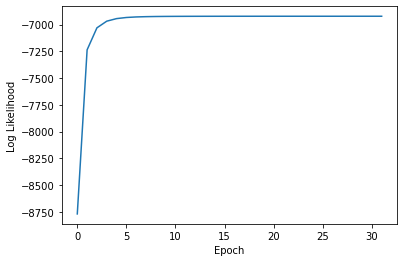

p[a]: [0.29399155 0.38311672 0.32289173]
phat[a]: [0.28708792 0.35468835 0.35822374]
p[h]: [[0.39873888 0.31476471 0.20665257 0.13284953]
 [0.03128721 0.27879818 0.28333014 0.36369784]
 [0.20367005 0.11526534 0.02242566 0.03512425]
 [0.36630386 0.29117177 0.48759164 0.46832838]]
phat[h]: [[0.34816684 0.35762343 0.18305705 0.15985462]
 [0.03555029 0.31756125 0.26733953 0.3790502 ]
 [0.23494157 0.09046424 0.01298599 0.01313937]
 [0.3813413  0.23435108 0.53661744 0.44795582]]


In [13]:
import matplotlib.pyplot as plt
plt.plot(list(range(iter+1)), logLikelihoodAll)
plt.xlabel('Epoch')
plt.ylabel('Log Likelihood')
plt.show()

# sanity checks to check if `phat` has converged close to `p`
print("p[a]: " + str(p["a"]))
print("phat[a]: " + str(phat["a"]))

print("p[h]: " + str(p["h"]))
print("phat[h]: " + str(phat["h"]))